### **👩‍🏫 👩🏿‍🏫 What You'll learn**

- Master statistical analysis of financial data using `NumPy` and `SciPy`.
- Learn effective data visualization techniques with `Matplotlib` for financial trends.
- Apply hypothesis testing to financial datasets for meaningful insights.
- Understand and utilize advanced statistical techniques in `NumPy` and `SciPy`.

---

### **Project Description**

Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:

### **Initial Data Exploration**

- Load the dataset using `Pandas`. Check for null values and understand data types.
- Examine the time series properties of the data (e.g., frequency, trends).

### **Data Visualization**

- Utilize `Matplotlib` to plot closing prices and traded volume over time.
- Create a candlestick chart to depict high and low prices.

### **Statistical Analysis**

- Compute summary statistics (mean, median, standard deviation) for key columns.
- Analyze closing prices with a moving average.

### **Hypothesis Testing**

- Execute a t-test to compare average closing prices across different years.
- Examine daily returns' distribution and test for normality using `SciPy`.

### **Advanced Statistical Techniques (Bonus)**

- Statistical Functions in `NumPy`: Employ `NumPy`'s statistical functions for in-depth stock data analysis.
    - E.g., Use `convolve` for moving averages, or `np.corrcoef` to explore correlations between financial metrics.
    - Analyze correlations between moving averages of closing prices and trading volume across time periods.

### **Resources**

- Dataset: download it here [Apple Stock Prices From 1981 to 2023](https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip)

It may include data such as date, opening price, closing price, high and low prices, and trading volume.
This information can be used to study trends and patterns in the stock market and make informed investment decisions.

- Date: Represents the date of the stock price.
- Open: Represents the opening stock price on that date.
- High: Represents the highest stock price on that date.
- Low: Represents the lowest stock price on that date.
- Close: Represents the closing stock price on that date.
- Adj close: Represents the adjusted closing stock price on that date (taking into account corporate actions such as splits).
- Volume: Represents the number of shares traded on that date.

### **Project Submission**

Submit a Jupyter Notebook with :

- All analysis code and visualizations.
- Detailed explanations of findings at each step.
- A comprehensive summary of insights, focusing on advanced statistical analysis.
- A 'Reflection' section detailing challenges and solutions.

### **Suggested structure**

1. Data Loading and Exploration
2. Data Visualization
3. Statistical Analysis
4. Hypothesis Testing
5. Advanced Statistical Techniques (Bonus)
    - Signal Processing using SciPy
    - Statistical Functions in NumPy
6. Summary and Insights
7. Reflection

### **Guidance**

- Experiment with different filters and parameters in signal processing techniques.
- Thoroughly understand each statistical function and its insights on the stock data.


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [4]:
# Convert the Date column from 'str' to 'datetime64'
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [6]:
df.describe(include="all")

,Date,Open,High,Low,Close,Adj Close,Volume
count,10608,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,2002-01-05 14:08:33.122172,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
min,1981-01-02 00:00:00,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,1991-06-27 18:00:00,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,2002-01-02 12:00:00,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,2012-07-13 18:00:00,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,2023-01-27 00:00:00,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09
std,NaN,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


In [7]:
# Are the dates sorted
df["Date"].is_monotonic_increasing

True

In [8]:
# Check if there are any gaps between dates
df["Date"].diff().value_counts()

Date
1 days    8317
3 days    1927
4 days     265
2 days      95
5 days       2
7 days       1
Name: count, dtype: int64

In [12]:
gap = df["Date"].diff()
idx = df[gap == pd.Timedelta(days=7)].index
df.loc[idx.union(idx - 1)]

,Date,Open,High,Low,Close,Adj Close,Volume
5228,2001-09-10,0.303571,0.312500,0.302143,0.310179,0.264402,308845600
5229,2001-09-17,0.285714,0.304821,0.280893,0.303393,0.258618,458007200


In [9]:
df["Date"].duplicated().sum()

np.int64(0)

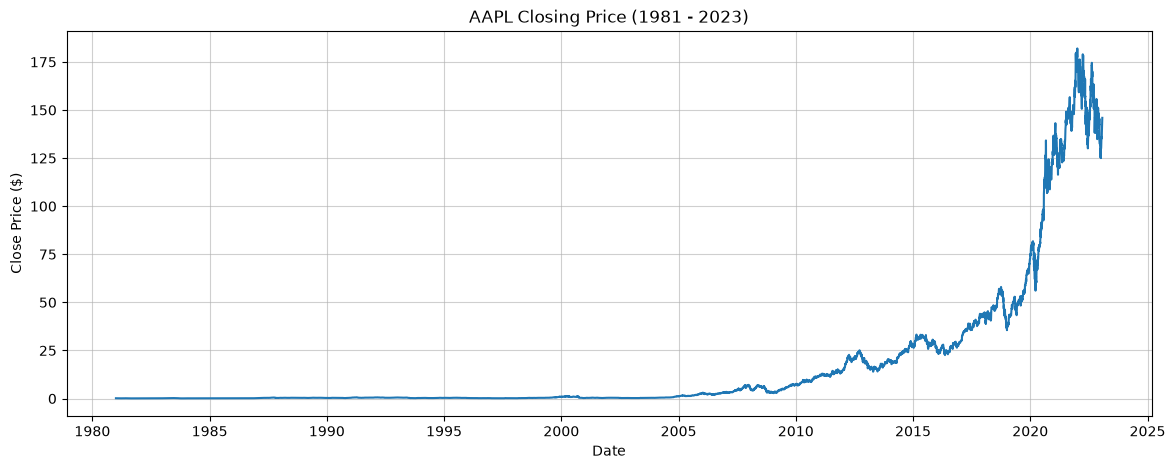

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"])
plt.title("AAPL Closing Price (1981 - 2023)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(alpha=0.6)
plt.show()

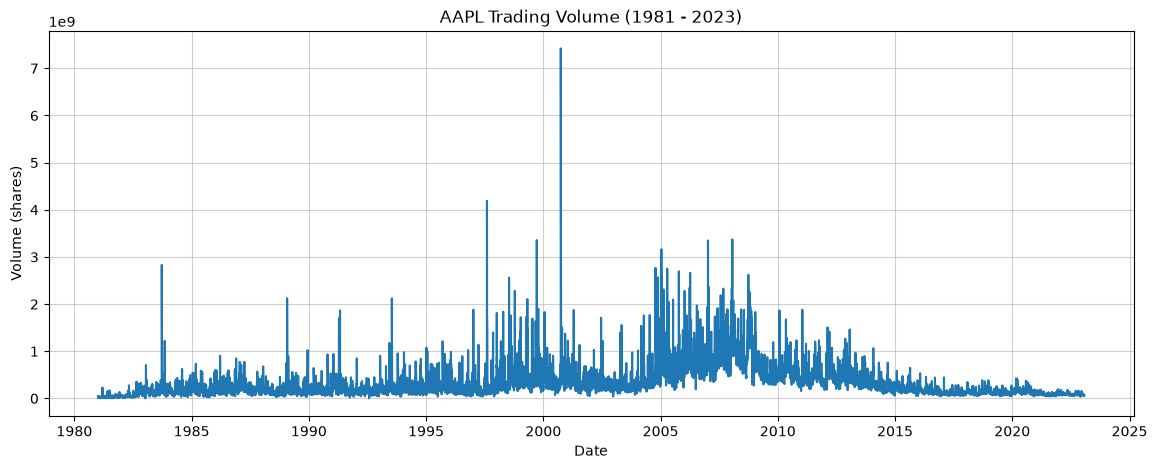

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("AAPL Trading Volume (1981 - 2023)")
plt.xlabel("Date")
plt.ylabel("Volume (shares)")
plt.grid(alpha=0.6)
plt.show()

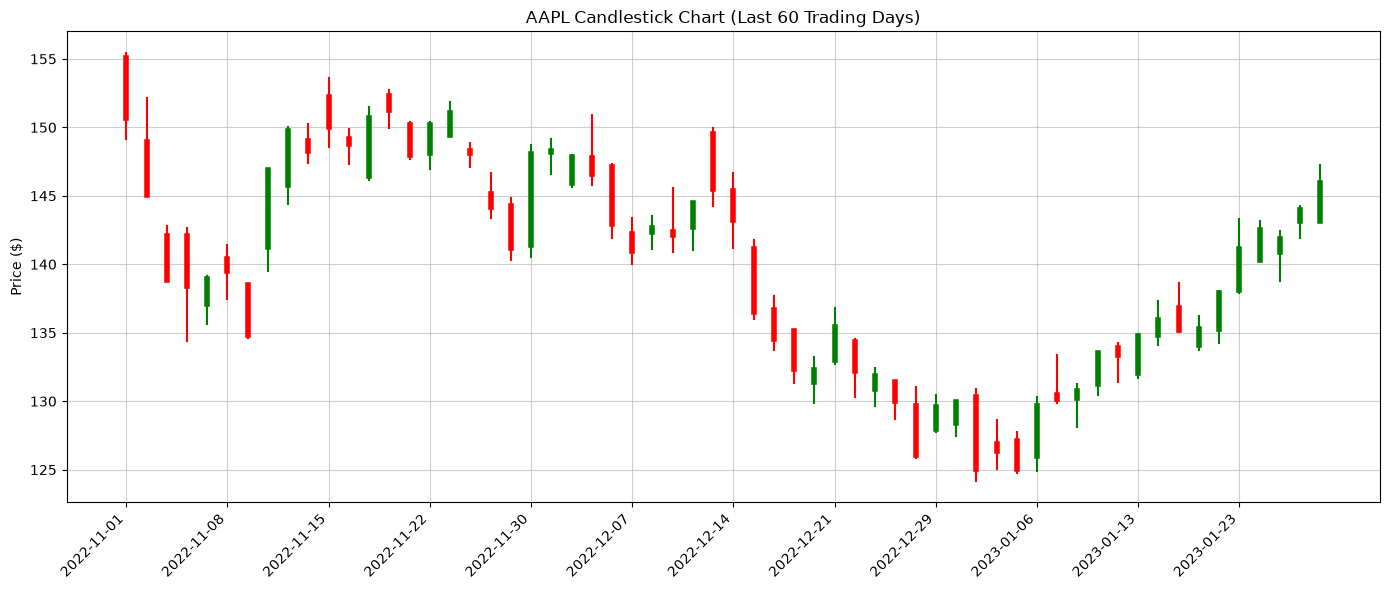

In [ ]:
recent = df.tail(60).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

for i, row in recent.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([i, i], [row["Low"], row["High"]], color=color)
    ax.plot([i, i], [row["Open"], row["Close"]], color=color, linewidth=4)

ax.set_xticks(range(0, len(recent), 5))
ax.set_xticklabels(
    recent["Date"].dt.strftime("%Y-%m-%d").iloc[::5], rotation=45, ha="right"
)
ax.set_title("AAPL Candlestick Chart (Last 60 Trading Days)")
ax.set_ylabel("Price ($)")
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
key_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

summary = df[key_cols].agg(["mean", "median", "std"])

summary

,Open,High,Low,Close,Adj Close,Volume
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
median,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


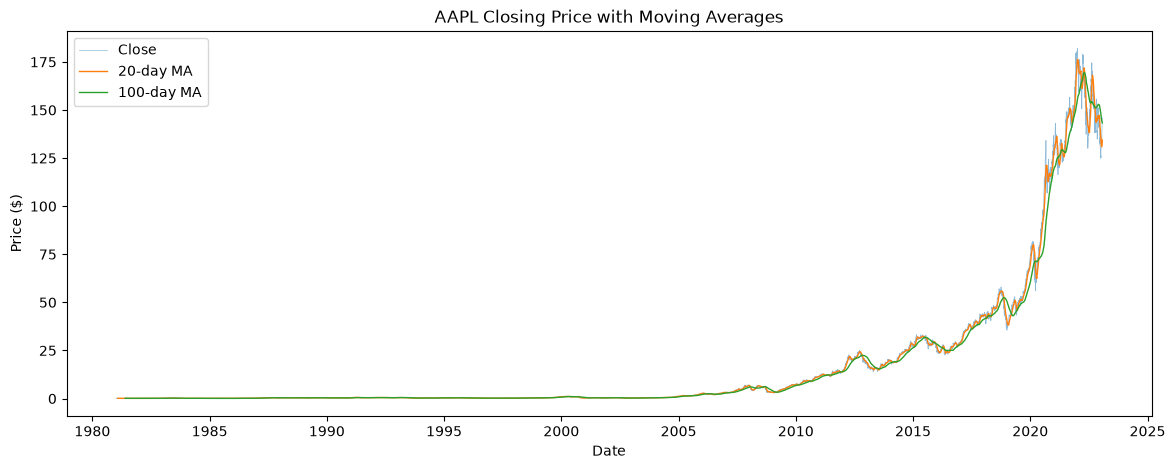

In [ ]:
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_100"] = df["Close"].rolling(window=100).mean()

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"], label="Close", linewidth=0.5, alpha=0.5)
plt.plot(df["Date"], df["MA_20"], label="20-day MA", linewidth=1)
plt.plot(df["Date"], df["MA_100"], label="100-day MA", linewidth=1)
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

In [22]:
# How often is price above vs. below its moving average.
above_ma20 = (df["Close"] > df["MA_20"]).mean() * 100
above_ma100 = (df["Close"] > df["MA_100"]).mean() * 100
print(f"Close above 20-day MA: {above_ma20:.1f}% of days")
print(f"Close above 100-day MA: {above_ma100:.1f}% of days")

Close above 20-day MA: 56.0% of days
Close above 100-day MA: 61.8% of days


In [ ]:
# The spread between price and its moving average.
df["Dev_MA20"] = df["Close"] - df["MA_20"]
df["Dev_MA20"].describe()

count    10589.000000
mean         0.123580
std          1.825650
min        -16.634001
25%         -0.017089
50%          0.004408
75%          0.073577
max         17.170996
Name: Dev_MA20, dtype: float64

In [ ]:
df["Year"] = df["Date"].dt.year

years = sorted(df["Year"].unique())

results = []
for y1, y2 in zip(years[:-1], years[1:]):
    a = df.loc[df["Year"] == y1, "Close"]
    b = df.loc[df["Year"] == y2, "Close"]
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    results.append(
        {
            "year_pair": f"{y1}-{y2}",
            "mean_1": a.mean(),
            "mean_2": b.mean(),
            "p_value": p_val,
        }
    )

pd.DataFrame(results)

,year_pair,mean_1,mean_2,p_value
0,1981-1982,0.108548,0.085459,1.153055e-23
1,1982-1983,0.085459,0.167274,2.082319e-66
2,1983-1984,0.167274,0.119651,1.438182e-32
3,1984-1985,0.119651,0.090233,6.432532e-64
4,1985-1986,0.090233,0.144913,1.027048e-99
5,1986-1987,0.144913,0.347751,1.219252e-124
6,1987-1988,0.347751,0.370884,4.863445e-06
7,1988-1989,0.370884,0.371953,6.956337e-01
8,1989-1990,0.371953,0.335373,3.176730e-23
9,1990-1991,0.335373,0.468701,2.784920e-99


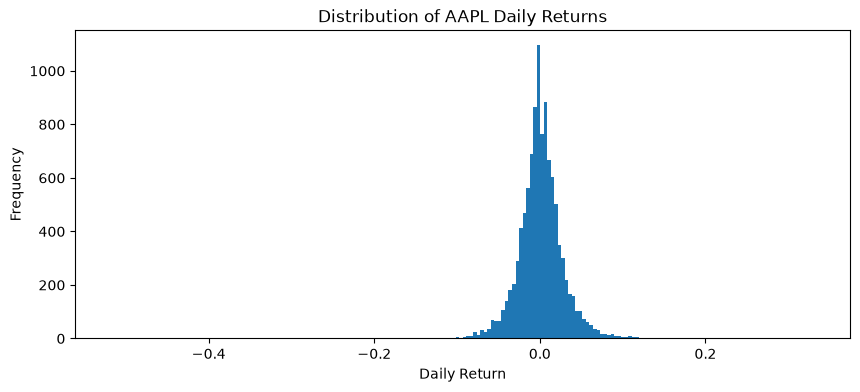

p-value: 0


In [27]:
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(10, 4))
plt.hist(df["Daily_Return"].dropna(), bins=200)
plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

stat, p_value = stats.normaltest(df["Daily_Return"].dropna())
print(f"p-value: {p_value:.4g}")

### Summary and Insights

**Data quality:** The dataset (10,608 trading days, 1981–2023) is clean - no nulls, no duplicate dates, dates monotonically increasing. The one irregular gap (7 days, Sep 10 - Sep 17, 2001) isn't a data issue - it's the closure following the September 11 attacks.

**Trend:** AAPL was essentially flat and low-priced for its first ~25 years (median close of just $0.49 across the full history reflects this), then entered a sustained climb from roughly 2010 onward, closing near $135–155 by 2021–2023.

**Moving averages:** Close price sat above its 100-day MA 61.8% of the time, vs. only 56.0% above the faster 20-day MA - the slower MA giving the higher percentage is itself a signature of long-run upward drift rather than noise, consistent with the trend above.

**Year-over-year price differences:** A t-test on consecutive year pairs showed most transitions were highly statistically significant, which tracks the overall trend. Three pairs were notable exceptions - 1988–1989 (p=0.696), 2002–2003 (p=0.083), and 2008–2009 (p=0.142) - years where the price plateaued rather than moved; 2008–2009 lines up with the financial crisis stalling growth. (Note: 2023 data only runs through Jan 27, so the
final 2022–2023 pair compares a full year to a partial month and isn't a fair comparison.)

**Daily returns are not normal:** `scipy.stats.normaltest` on daily returns p ≈ 0 - strongly rejecting normality. This matches what's well documented about real stock returns.
Fat tails and occasional extreme daily moves that a normal distribution would essentially never predict.


### Reflection

**Challenges:**

- Cell execution order mattered more than expected - running `describe()` before converting `Date` to datetime silently gave a less useful summary (count/unique/top/freq instead of min/max/mean). Reordering cells so the conversion happens first fixed this.
- Candlestick charts aren't a built-in Matplotlib type, so it had to be built manually from line segments (wick + body), and plotting all 10,608 days at once was unreadable - restricting to the most recent 60 trading days was necessary to make the chart legible.

**Solutions:**

- Investigated anomalies rather than dismissing them - the single 7-day date gap turned out to be a real, explainable event (9/11 market closure) rather than a data quality problem.
- Chose Welch's t-test (`equal_var=False`) over the standard independent t-test since there's no reason to assume equal variance between arbitrary year pairs.
- Treated statistically significant year-over-year differences with some skepticism rather than taking p-values at face value - given AAPL's long upward trend, most pairs were "expected" to differ, so the more informative signal was the handful of pairs that _didn't_ differ significantly.
